Multi env

In [1]:
# install.packages("renv")
# renv::init()
# renv::install("tidymodels")
# renv::install("lorax")
# renv::install("ranger")

In [2]:
library(tidymodels) # <- to easily get dplyr, tidyr, ggplot2, etc
library(ranger)
library(lorax)

── Attaching packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels 1.5.0 ──
✔ broom        1.0.13     ✔ recipes      1.3.3 
✔ dials        1.4.4      ✔ rsample      1.3.2 
✔ dplyr        1.2.1      ✔ tailor       0.1.0 
✔ ggplot2      4.0.3      ✔ tidyr        1.3.2 
✔ infer        1.1.0      ✔ tune         2.1.0 
✔ modeldata    1.5.1      ✔ workflows    1.3.0 
✔ parsnip      1.6.0      ✔ workflowsets 1.1.1 
✔ purrr        1.2.2      ✔ yardstick    1.4.0 
── Conflicts ────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidymodels_conflicts() ──
✖ purrr::discard() masks scales::discard()
✖ dplyr::filter()  masks stats::filter()
✖ dplyr::lag()     masks stats::lag()
✖ recipes::step()  masks stats::step()
• Search for functions across packages at https://www.tidymodels.org/find/


Random Samples

In [3]:
set.seed(872)
rgr_fit <-
  ranger(
    time_to_delivery ~ .,
    data = modeldata::deliveries,
    num.trees = 1000,
    min.node.size = 5000,
    importance = "impurity"
  )

rgr_fit

Ranger result

Call:
 ranger(time_to_delivery ~ ., data = modeldata::deliveries, num.trees = 1000,      min.node.size = 5000, importance = "impurity") 

Type:                             Regression 
Number of trees:                  1000 
Sample size:                      10012 
Number of independent variables:  30 
Mtry:                             5 
Target node size:                 5000 
Variable importance mode:         impurity 
Splitrule:                        variance 
OOB prediction error (MSE):       24.26389 
R squared (OOB):                  0.4879119 

Visualise the tree

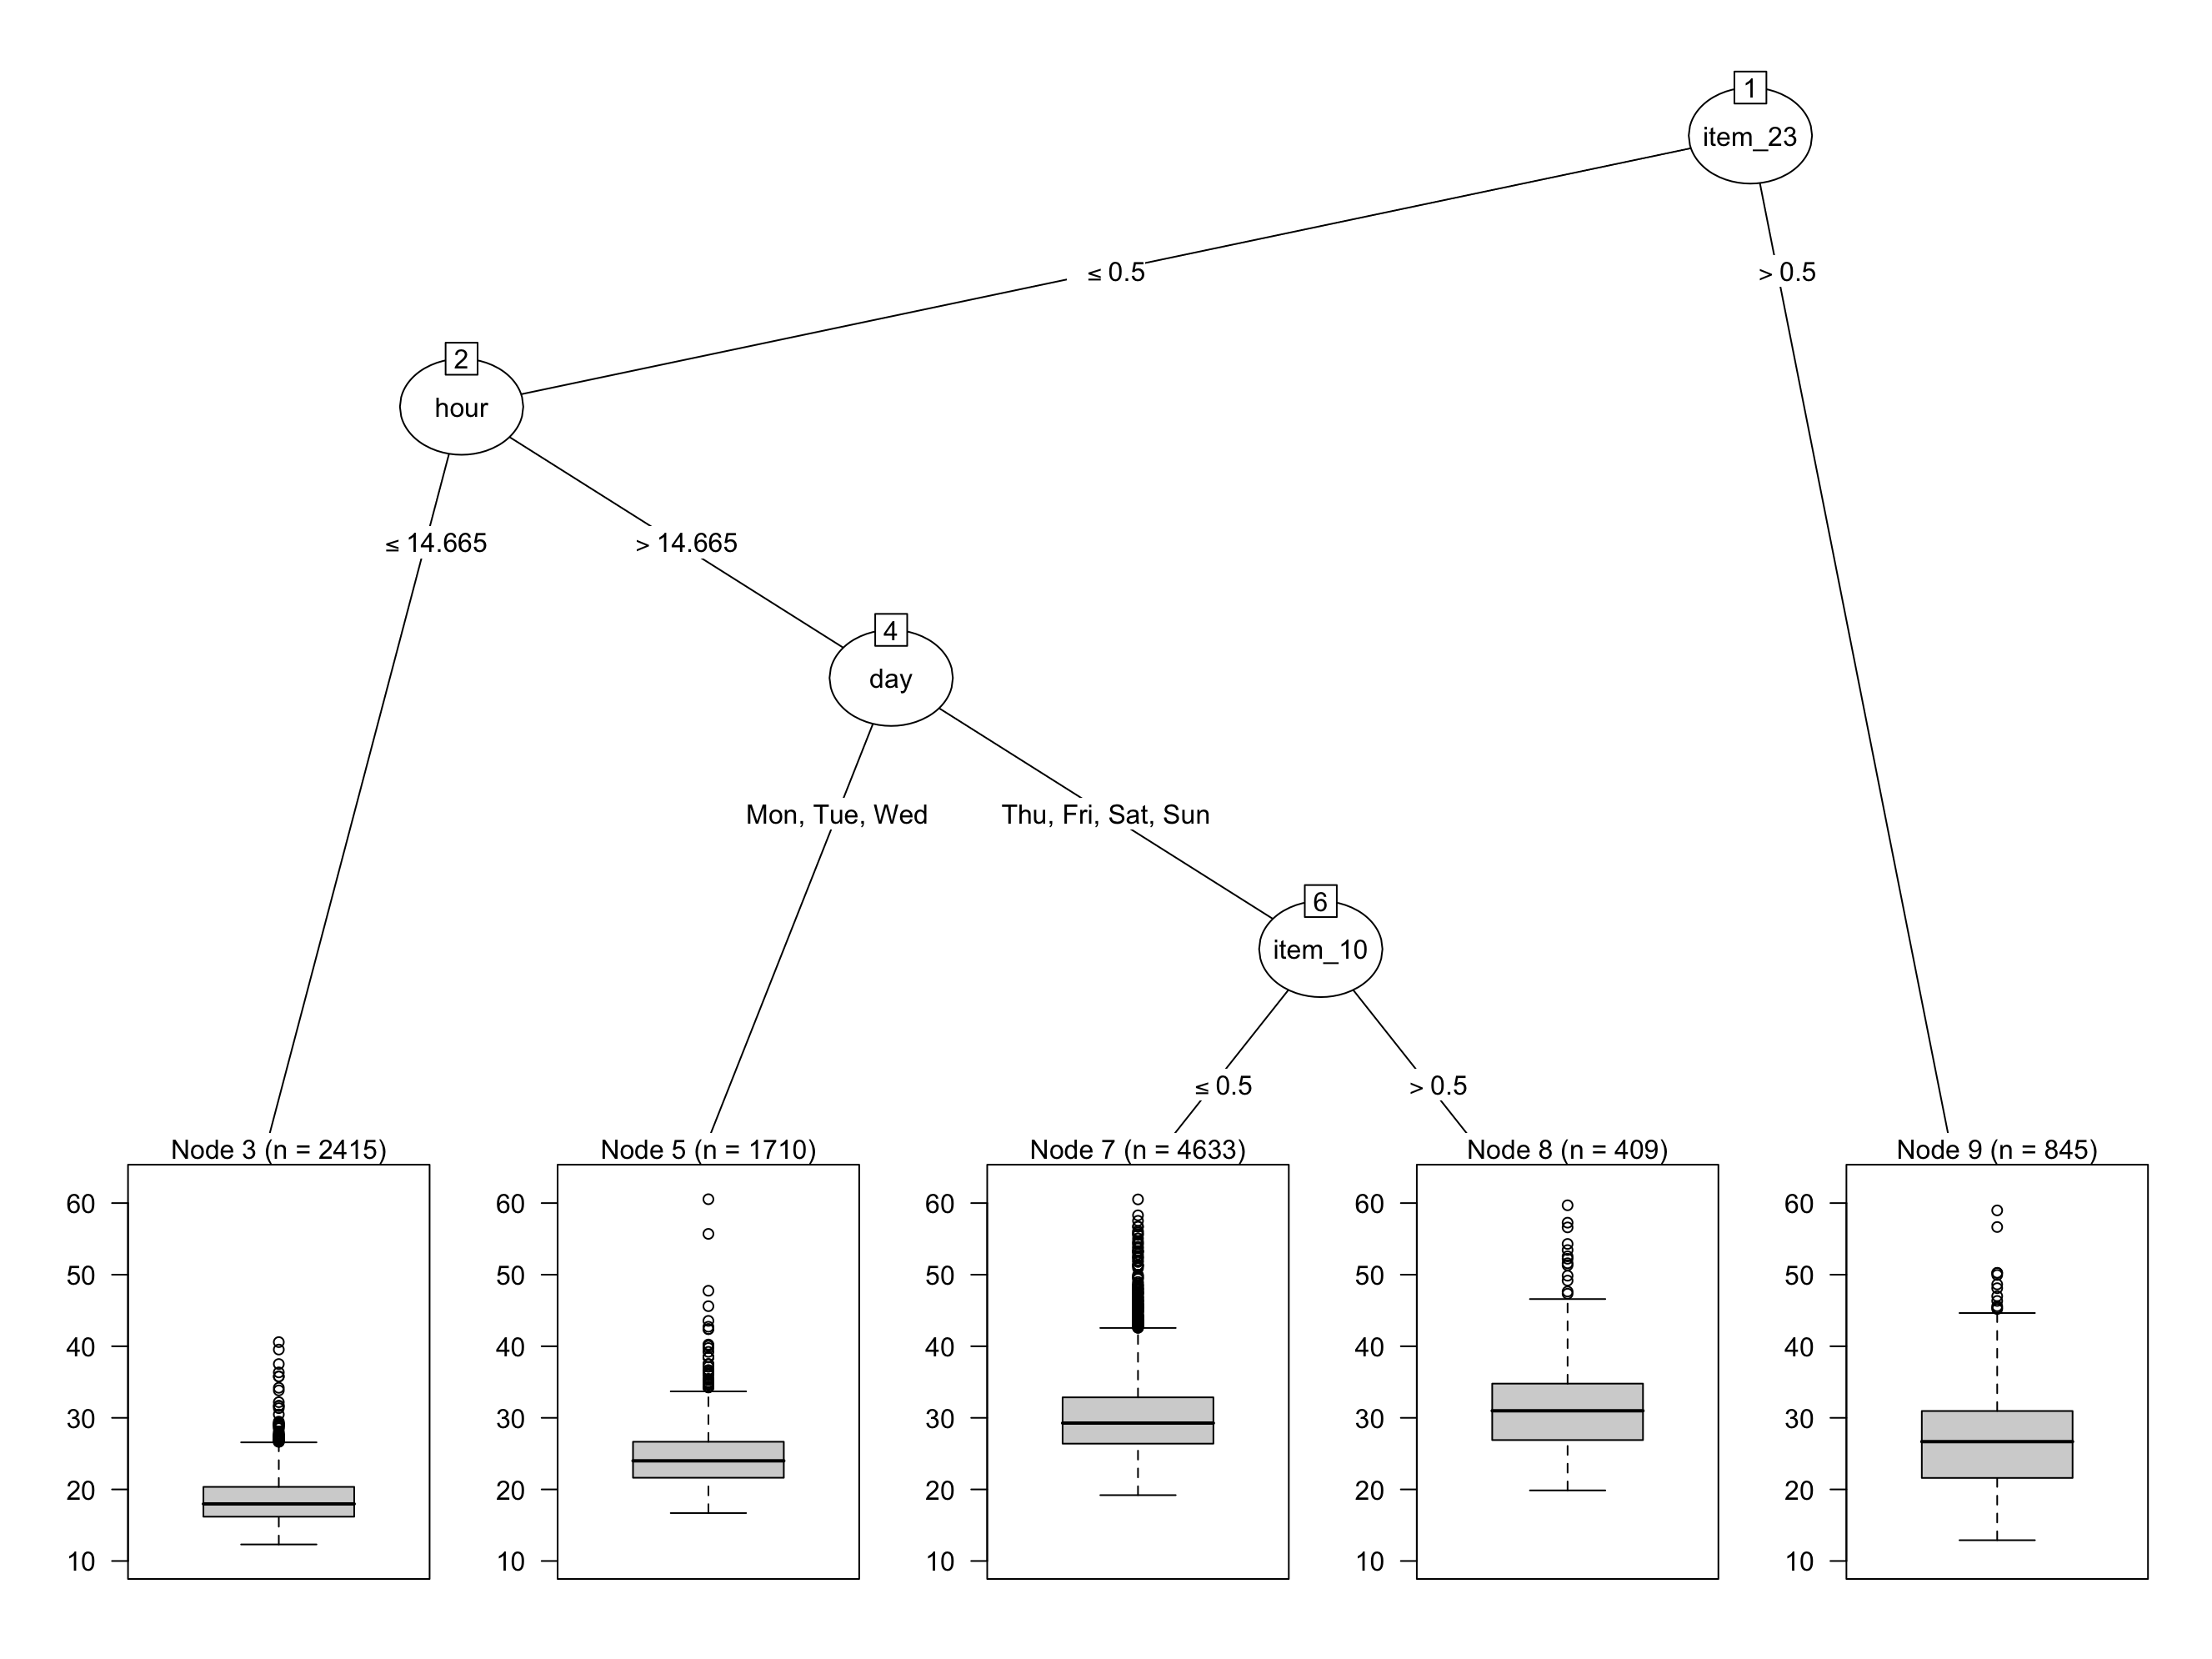

In [4]:
rgr_fit |>
  as.party(tree = 1, data = modeldata::deliveries) |>
  plot()

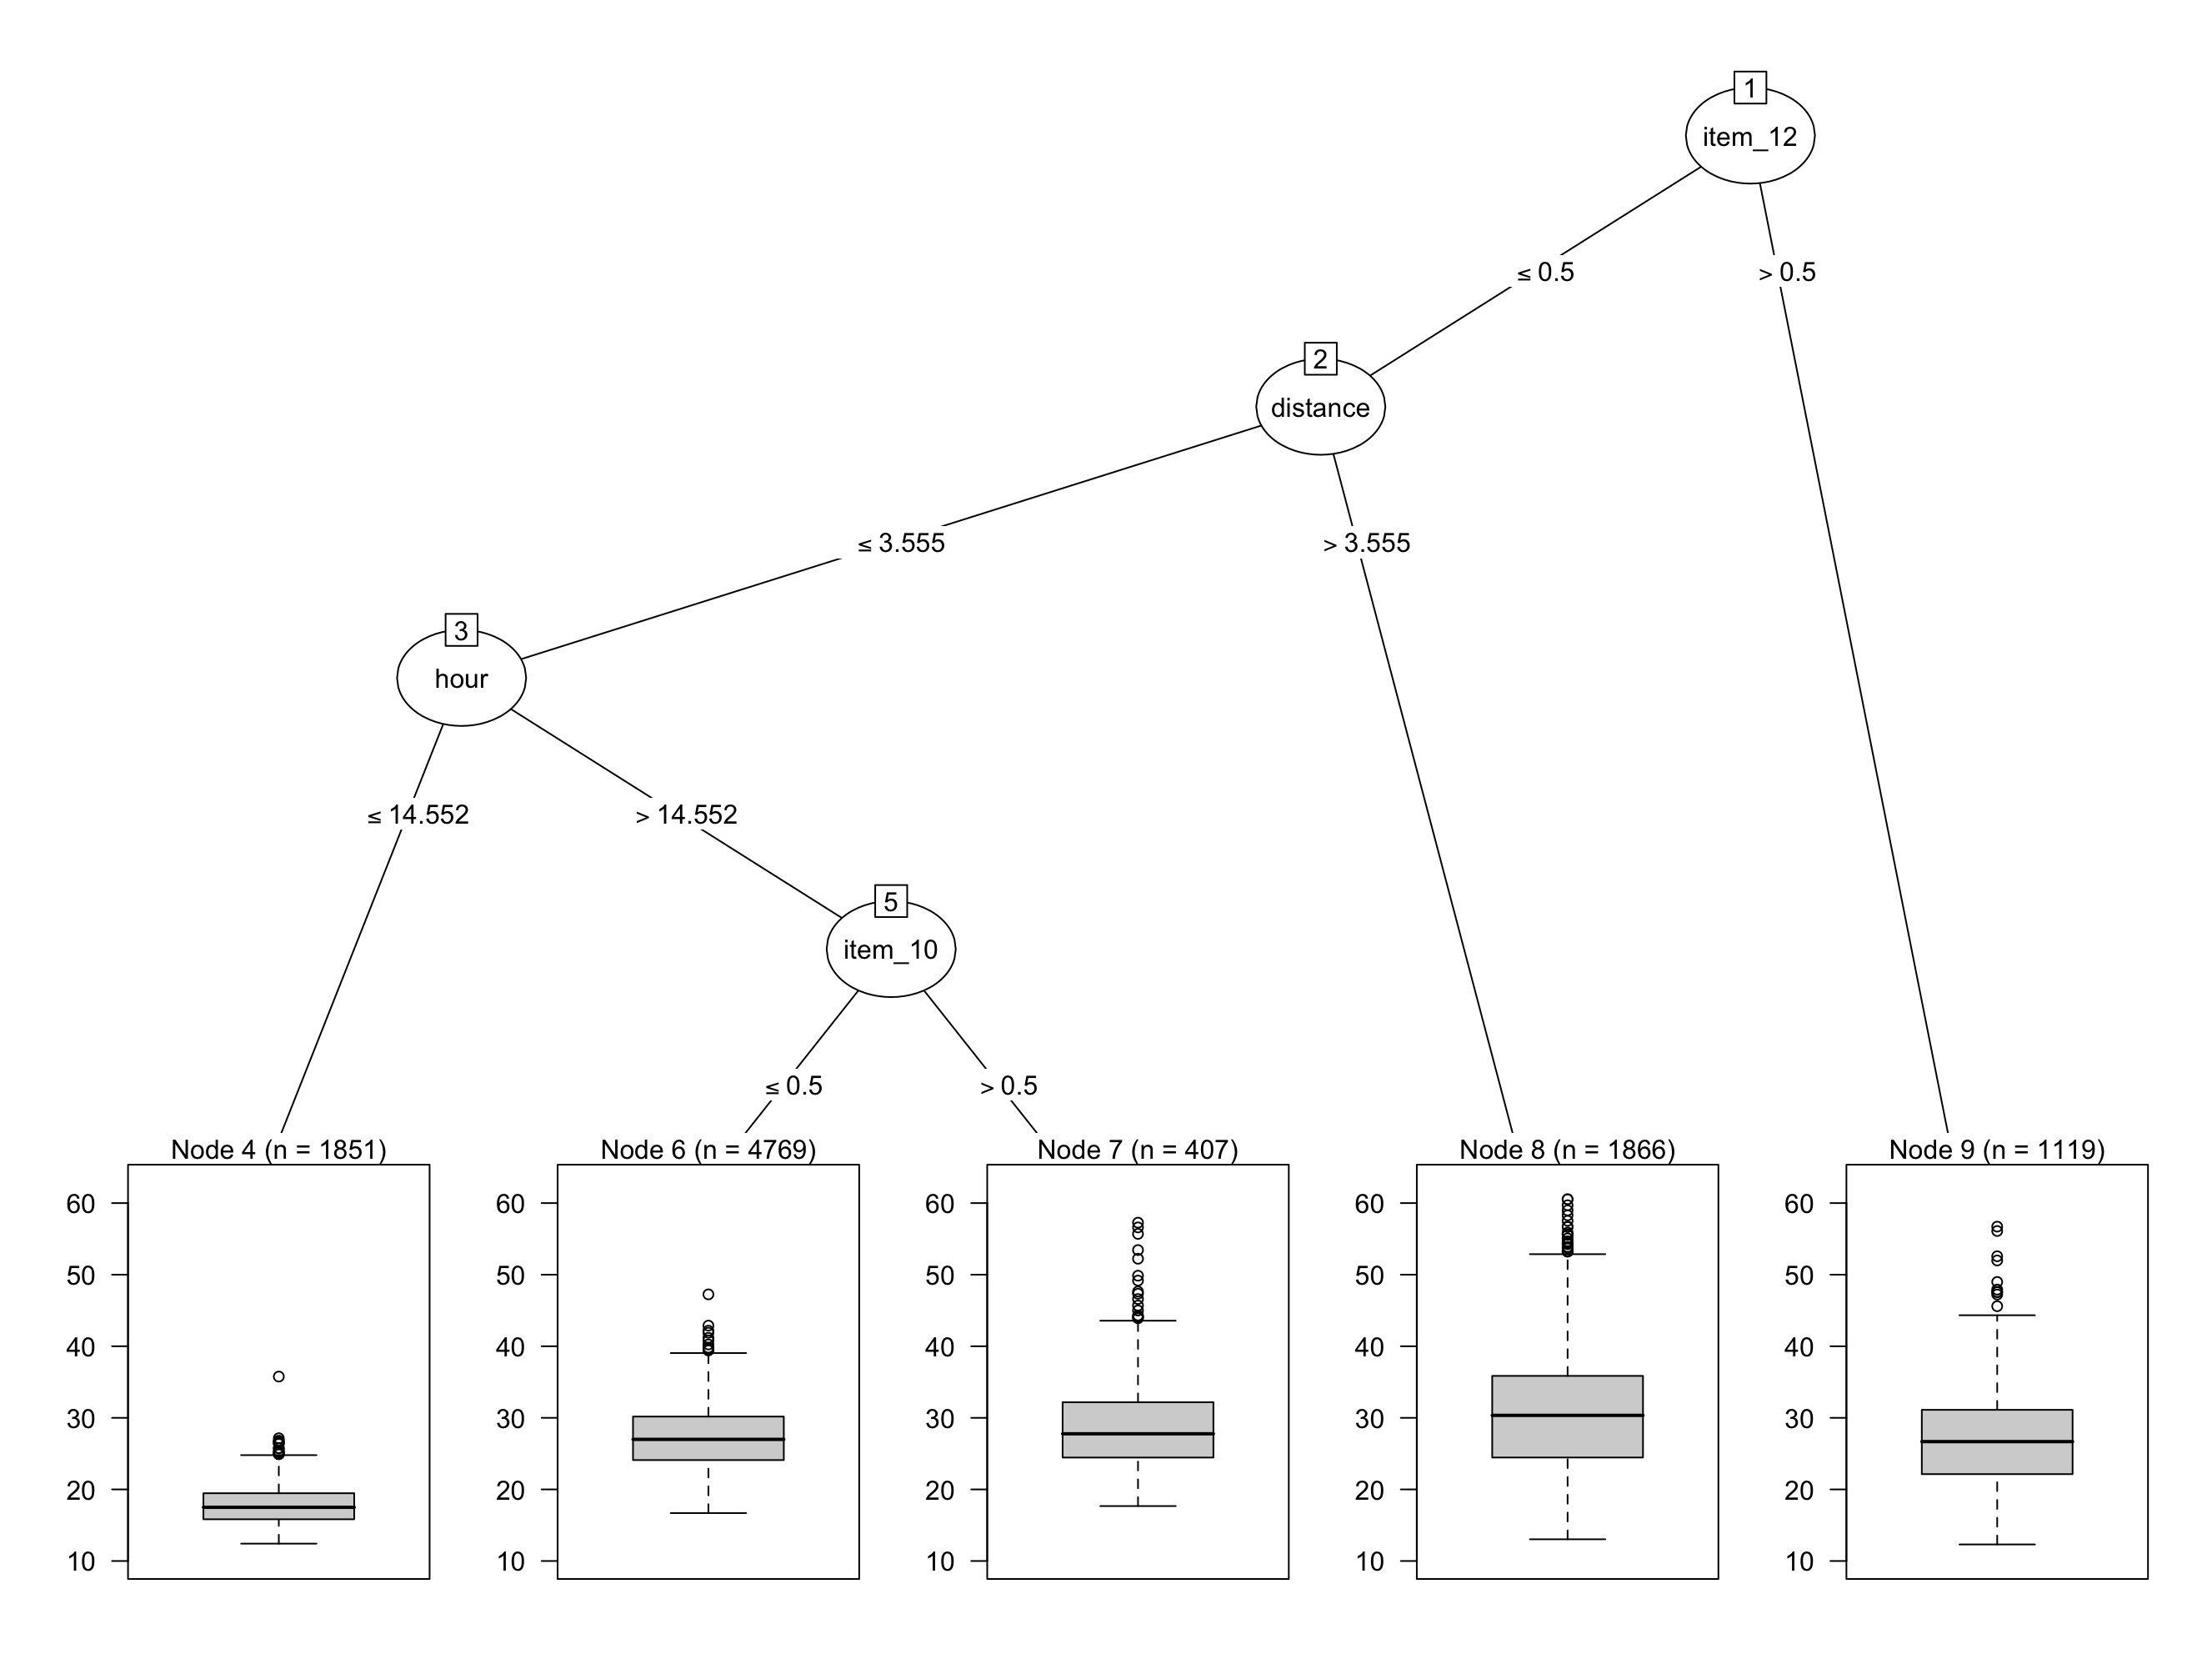

In [5]:
rgr_fit |>
  as.party(tree = 100, data = modeldata::deliveries) |>
  plot()

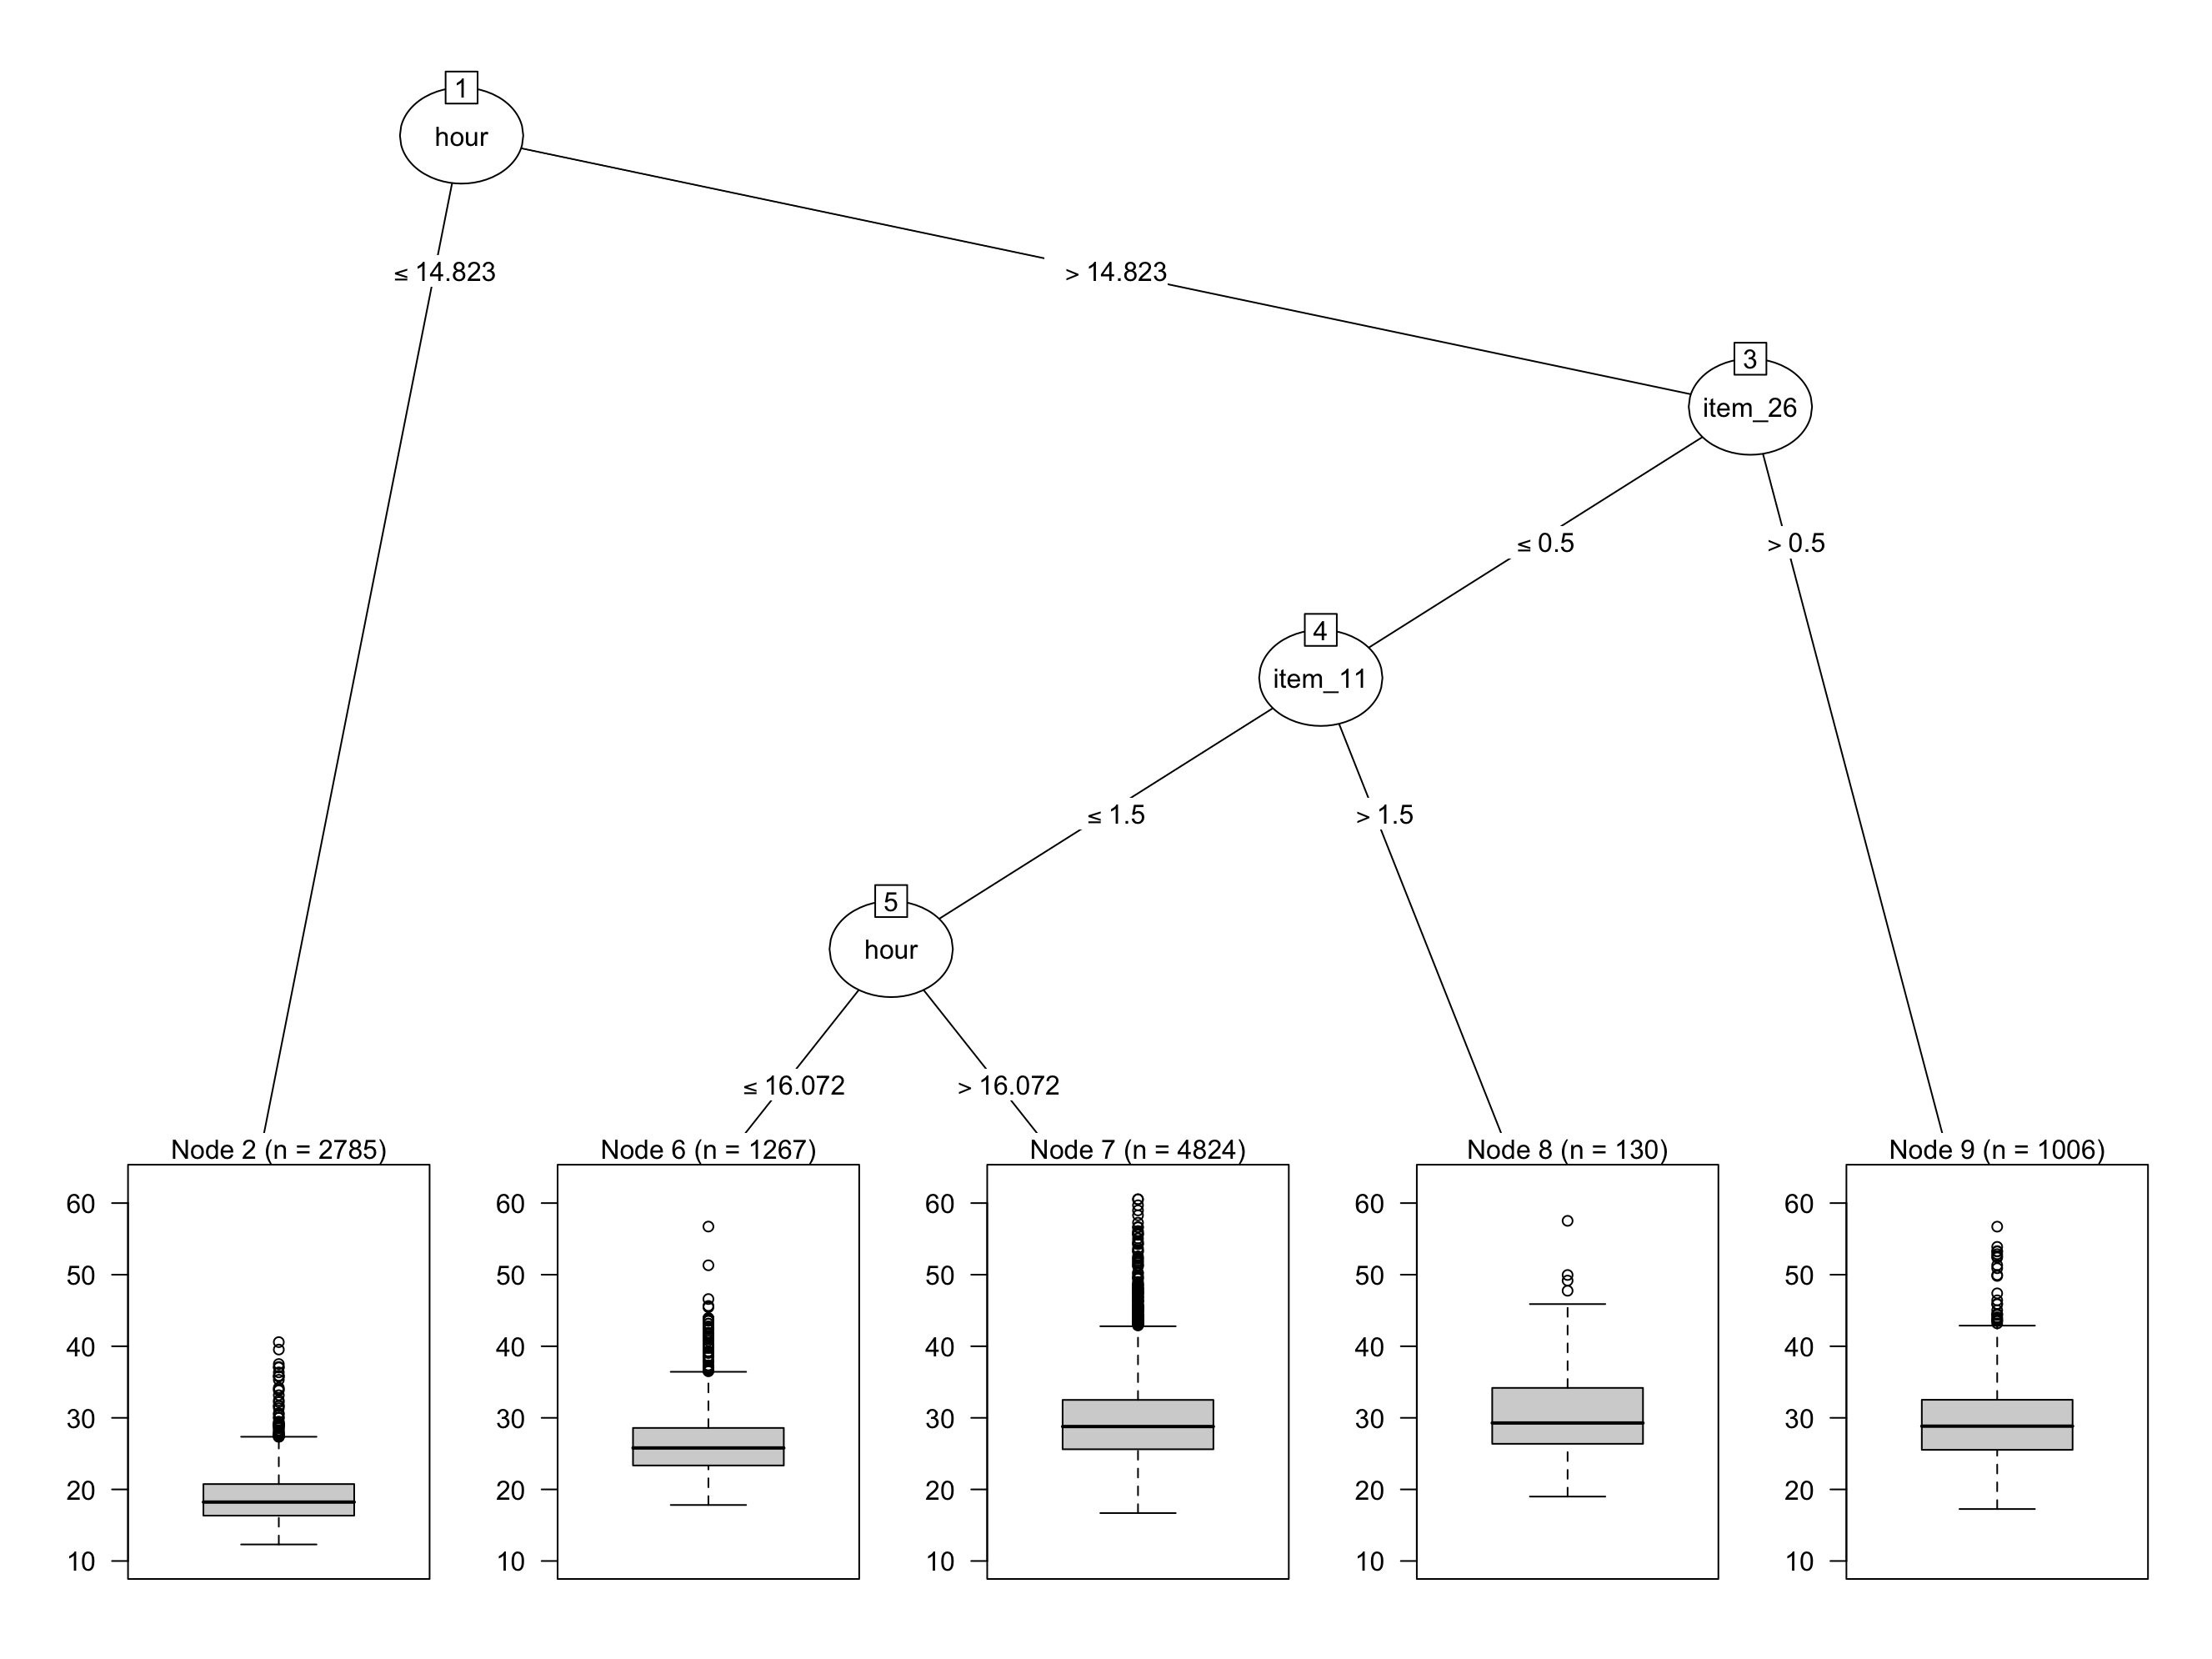

In [8]:
rgr_fit |>
  as.party(tree = 1000, data = modeldata::deliveries) |>
  plot()

In [6]:
# Extract and visualize variable importance from the ranger model
importance(rgr_fit) |>
  sort(decreasing = TRUE) |>
  head(10)

        hour     distance          day      item_01      item_10      item_26      item_27      item_24      item_12      item_02 
108891.64843  25688.89115  16053.51698    673.46649    480.18938    210.10180    181.09524    175.95373    102.08234     86.32399 

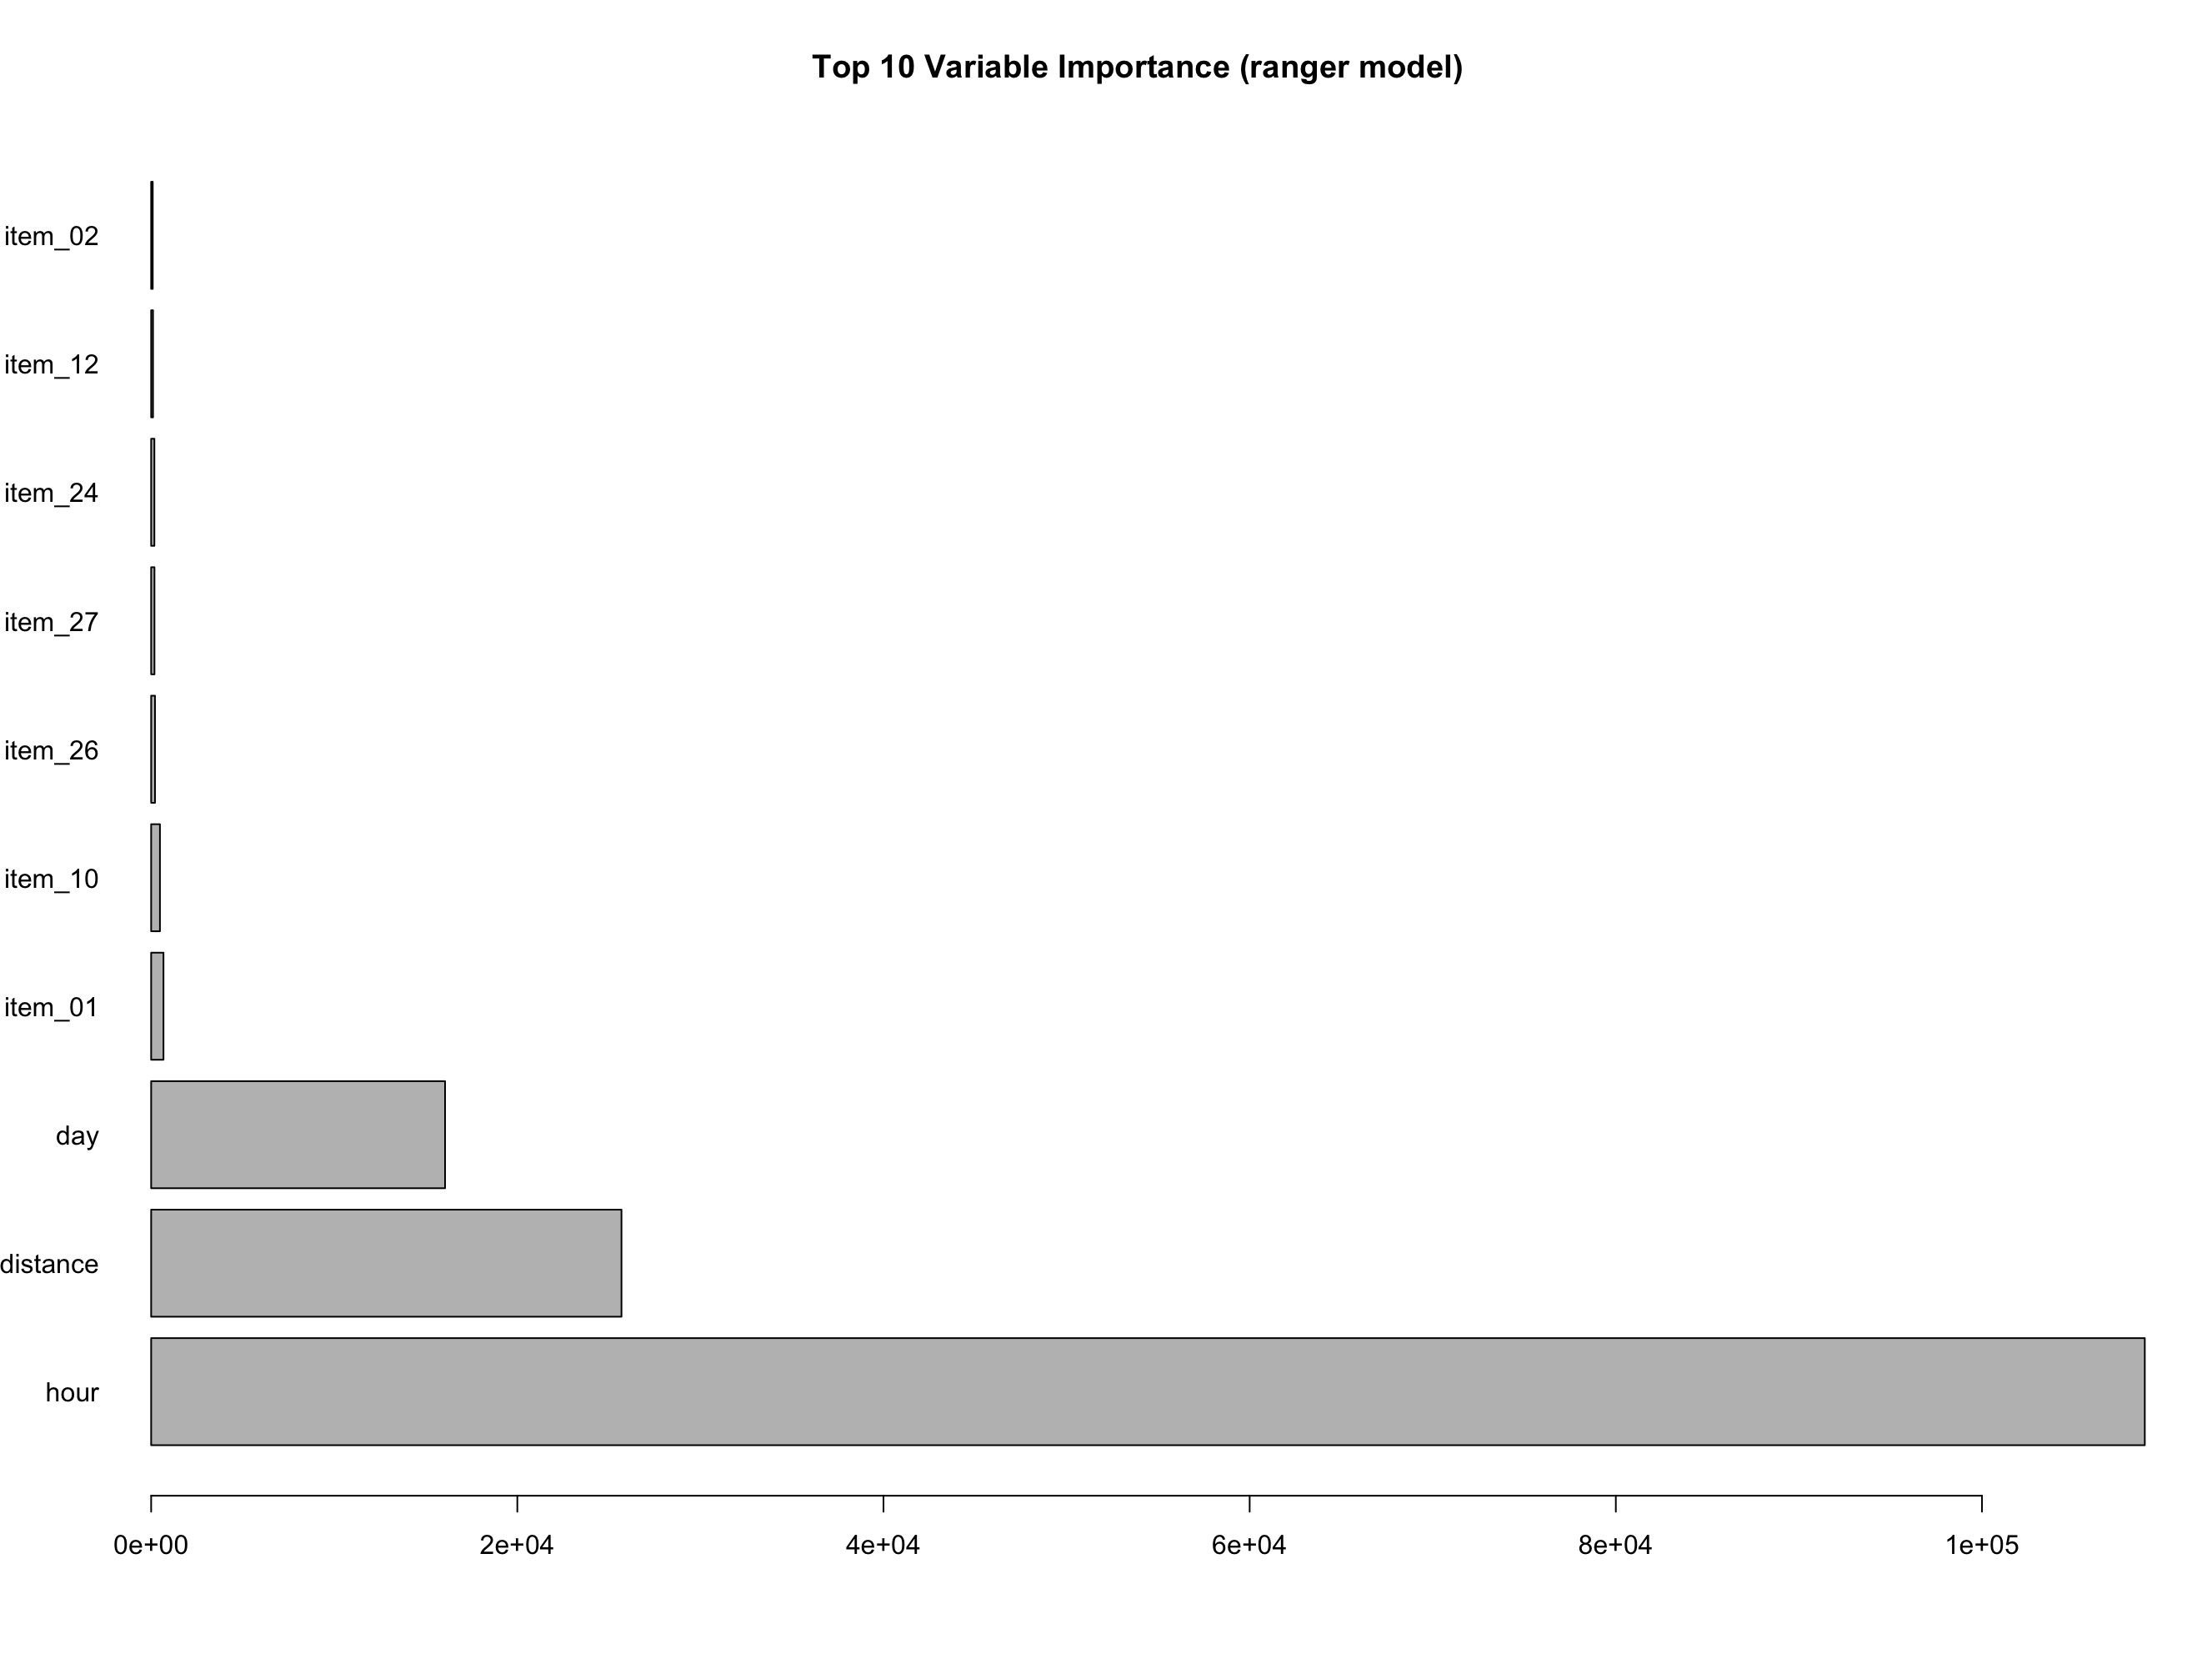

In [7]:
# Visualize top 10 variable importance scores
importance(rgr_fit) |>
  sort(decreasing = TRUE) |>
  head(10) |>
  barplot(horiz = TRUE, las = 1, main = "Top 10 Variable Importance (ranger model)")

Which prediction were used

In [9]:
rgr_vars <- active_predictors(rgr_fit, tree = 1:1000)
rgr_vars

# A tibble: 1,000 × 2
   active_predictors  tree
   <list>            <int>
 1 <chr [4]>             1
 2 <chr [5]>             2
 3 <chr [3]>             3
 4 <chr [4]>             4
 5 <chr [4]>             5
 6 <chr [3]>             6
 7 <chr [3]>             7
 8 <chr [7]>             8
 9 <chr [3]>             9
10 <chr [6]>            10
# ℹ 990 more rows
# ℹ Use `print(n = ...)` to see more rows

In [ ]:
# The column names are in a nested vector
rgr_vars$active_predictors[[1]]

[1] "day"     "hour"    "item_10" "item_23"

In [ ]:
# Expand the list
rgr_vars |>
  unnest(cols = c(active_predictors))

# A tibble: 4,306 × 2
   active_predictors  tree
   <chr>             <int>
 1 day                   1
 2 hour                  1
 3 item_10               1
 4 item_23               1
 5 day                   2
 6 distance              2
 7 item_10               2
 8 item_12               2
 9 item_26               2
10 hour                  3
# ℹ 4,296 more rows
# ℹ Use `print(n = ...)` to see more rows

How often are the predictors being used

In [12]:
rgr_vars |>
  unnest(cols = c(active_predictors)) |>
  count(active_predictors) |>
  arrange(active_predictors)

# A tibble: 30 × 2
   active_predictors     n
   <chr>             <int>
 1 day                 516
 2 distance            507
 3 hour                623
 4 item_01             329
 5 item_02             131
 6 item_03              57
 7 item_04              66
 8 item_05              26
 9 item_06              92
10 item_07              91
# ℹ 20 more rows
# ℹ Use `print(n = ...)` to see more rows

How many predictors are used in each rule (on average)? A rule is the full logical statement that defines the path to the terminal nodes.

In [13]:
rgr_vars |>
  mutate(num_vars = map_int(active_predictors, ~ length(.x))) |>
  summarize(mean_num_vars = mean(num_vars))

# A tibble: 1 × 1
  mean_num_vars
          <dbl>
1          4.31

Many packages can compute variable importance scores for each predictor but each has a different interface. The lorax package has an accessor function to pull these from the model called `var_imp()`

In [14]:
var_imp(rgr_fit)

# A tibble: 30 × 2
   term     estimate
   <chr>       <dbl>
 1 hour     108892. 
 2 day       16054. 
 3 distance  25689. 
 4 item_01     673. 
 5 item_02      86.3
 6 item_03      30.4
 7 item_04      43.7
 8 item_05      11.0
 9 item_06      50.1
10 item_07      55.2
# ℹ 20 more rows
# ℹ Use `print(n = ...)` to see more rows

# Examining Rules

We can also get detailed information on the model’s rules (for each tree). Using the same ranger model fit

In [15]:
rgr_rules <- extract_rules(rgr_fit, data = modeldata::deliveries)
rgr_rules

# A tibble: 5 × 3
     id rules       tree
  <int> <list>     <int>
1     3 <language>     1
2     5 <language>     1
3     7 <language>     1
4     8 <language>     1
5     9 <language>     1

In [16]:
# With components
rgr_rules$rules[[1]] |> class()

[1] "call"

In [17]:
rgr_rules$rules[[1]]

item_23 <= 0.5 & hour <= 14.6645

We can compute on these and/or use them to determine which specific data were contained in the terminal node

In [18]:
modeldata::deliveries |> filter(!!rgr_rules$rules[[1]])

# A tibble: 2,415 × 31
   time_to_delivery  hour day   distance item_01 item_02 item_03 item_04 item_05 item_06 item_07 item_08 item_09 item_10 item_11 item_12 item_13 item_14 item_15 item_16 item_17 item_18
              <dbl> <dbl> <fct>    <dbl>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>   <int>
 1             16.1  11.9 Thu       3.15       0       0       2       0       0       0       0       0       0       1       1       0       0       0       0       0       0       0
 2             19.6  13.0 Sat       3.35       1       0       0       1       0       0       1       0       1       0       1       0       0       0       0       0       0       0
 3             17.4  11.9 Sun       2.75       0       2       1       0       0       0       0       0       0       0       0       1       0       0       0       0       1       1
 4             18.0  12.1 Tue       2.4        0    